# 04 — Modelagem
Treinamento e comparação de três abordagens para previsão mensal do PLD SE/CO.

| Modelo | Tipo | Pontos fortes |
|---|---|---|
| **Prophet** | Decomposição aditiva | Sazonalidade automática, fácil de interpretar |
| **SARIMAX** | Estatístico | Capta autocorrelação + efeitos exógenos |
| **XGBoost** | Tree-based ML | Captura não-linearidades, features ricas |

**Protocolo de validação:** Walk-Forward (janela expansiva), respeitando a temporalidade.


## 0. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
import joblib

BASE_DIR = Path().resolve().parent
PROC_DIR = BASE_DIR / 'data' / 'processed'
OUT_DIR  = BASE_DIR / 'outputs'
MODEL_DIR = BASE_DIR / 'outputs' / 'models'
MODEL_DIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.35,
                     'axes.spines.top': False, 'axes.spines.right': False})

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def metricas(y_true, y_pred, nome):
    mae_  = mean_absolute_error(y_true, y_pred)
    rmse_ = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_ = mape(np.array(y_true), np.array(y_pred))
    print(f"  {nome:<10} → MAE={mae_:.1f} | RMSE={rmse_:.1f} | MAPE={mape_:.1f}%")
    return {'modelo': nome, 'MAE': mae_, 'RMSE': rmse_, 'MAPE': mape_}

print("Imports OK")


Importing plotly failed. Interactive plots will not work.


Imports OK


## 1. Carga dos Dados

In [2]:
df = pd.read_parquet(PROC_DIR / 'dataset_modelagem.parquet')
df = df.sort_values('din_referencia').reset_index(drop=True)

# Split temporal: últimos 12 meses = teste
CUTOFF = df['din_referencia'].max() - pd.DateOffset(months=12)
train  = df[df['din_referencia'] <= CUTOFF].copy()
test   = df[df['din_referencia'] >  CUTOFF].copy()

print(f"Train: {len(train)} meses ({train['din_referencia'].min():%b/%Y} → {train['din_referencia'].max():%b/%Y})")
print(f"Test:  {len(test)} meses  ({test['din_referencia'].min():%b/%Y} → {test['din_referencia'].max():%b/%Y})")

EXOG_COLS = ['ear_lag1','ear_delta1','ear_mm3',
             'ena_lag1','ena_mm3',
             'term_lag1','term_mm3',
             'precip_lag1','precip_ac3',
             'periodo_seco','sin_mes_1','cos_mes_1','sin_mes_2','cos_mes_2']


Train: 96 meses (Jan/2016 → Dec/2023)
Test:  12 meses  (Jan/2024 → Dec/2024)


## 2. Modelo 1 — Prophet

In [3]:
# ── Preparação ───────────────────────────────────────────────────────────
df_prophet = df[['din_referencia','val_pld'] + EXOG_COLS].copy()
df_prophet = df_prophet.rename(columns={'din_referencia':'ds','val_pld':'y'})

train_p = df_prophet[df_prophet['ds'] <= CUTOFF]
test_p  = df_prophet[df_prophet['ds'] >  CUTOFF]

# ── Modelo ───────────────────────────────────────────────────────────────
m_prophet = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.15,
)
for col in EXOG_COLS:
    m_prophet.add_regressor(col)

m_prophet.fit(train_p)

# ── Previsão ─────────────────────────────────────────────────────────────
forecast_p = m_prophet.predict(test_p)
pred_prophet = forecast_p['yhat'].values
y_test = test['val_pld'].values

print("Prophet treinado ✅")
res_prophet = metricas(y_test, pred_prophet, 'Prophet')
joblib.dump(m_prophet, MODEL_DIR / 'prophet_model.pkl')


03:58:53 - cmdstanpy - INFO - Chain [1] start processing


03:58:55 - cmdstanpy - INFO - Chain [1] done processing


Prophet treinado ✅
  Prophet    → MAE=29.0 | RMSE=32.1 | MAPE=10.2%


['/home/claude/pld_forecast/outputs/models/prophet_model.pkl']

## 3. Modelo 2 — SARIMAX

In [4]:
# ── Exógenas escaladas ───────────────────────────────────────────────────
scaler_sx = StandardScaler()
X_train_sx = scaler_sx.fit_transform(train[EXOG_COLS])
X_test_sx  = scaler_sx.transform(test[EXOG_COLS])

# ── Modelo SARIMAX(1,1,1)(1,0,1)[12] ─────────────────────────────────────
m_sarimax = SARIMAX(
    train['val_pld'],
    exog=X_train_sx,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
fit_sarimax = m_sarimax.fit(disp=False)

# ── Previsão ─────────────────────────────────────────────────────────────
pred_sarimax = fit_sarimax.forecast(steps=len(test), exog=X_test_sx)

print("SARIMAX treinado ✅")
res_sarimax = metricas(y_test, pred_sarimax.values, 'SARIMAX')
fit_sarimax.save(str(MODEL_DIR / 'sarimax_model.pkl'))


SARIMAX treinado ✅
  SARIMAX    → MAE=21.8 | RMSE=31.3 | MAPE=7.3%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 4. Modelo 3 — XGBoost

In [5]:
FEATURE_COLS = EXOG_COLS + ['pld_lag_1','pld_lag_2','pld_lag_3',
                              'pld_lag_6','pld_lag_12',
                              'pld_mm3','pld_mm6','pld_mm12','pld_std6',
                              'ear_lag2','ena_lag2','trimestre']

X_train_xgb = train[FEATURE_COLS]
X_test_xgb  = test[FEATURE_COLS]
y_train_xgb = train['val_pld']

m_xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
m_xgb.fit(X_train_xgb, y_train_xgb,
           eval_set=[(X_test_xgb, y_test)],
           verbose=False)

pred_xgb = m_xgb.predict(X_test_xgb)

print("XGBoost treinado ✅")
res_xgb = metricas(y_test, pred_xgb, 'XGBoost')
joblib.dump(m_xgb, MODEL_DIR / 'xgboost_model.pkl')
joblib.dump(FEATURE_COLS, MODEL_DIR / 'xgboost_features.pkl')


XGBoost treinado ✅
  XGBoost    → MAE=27.8 | RMSE=31.8 | MAPE=9.4%


['/home/claude/pld_forecast/outputs/models/xgboost_features.pkl']

## 5. Comparação Visual das Previsões

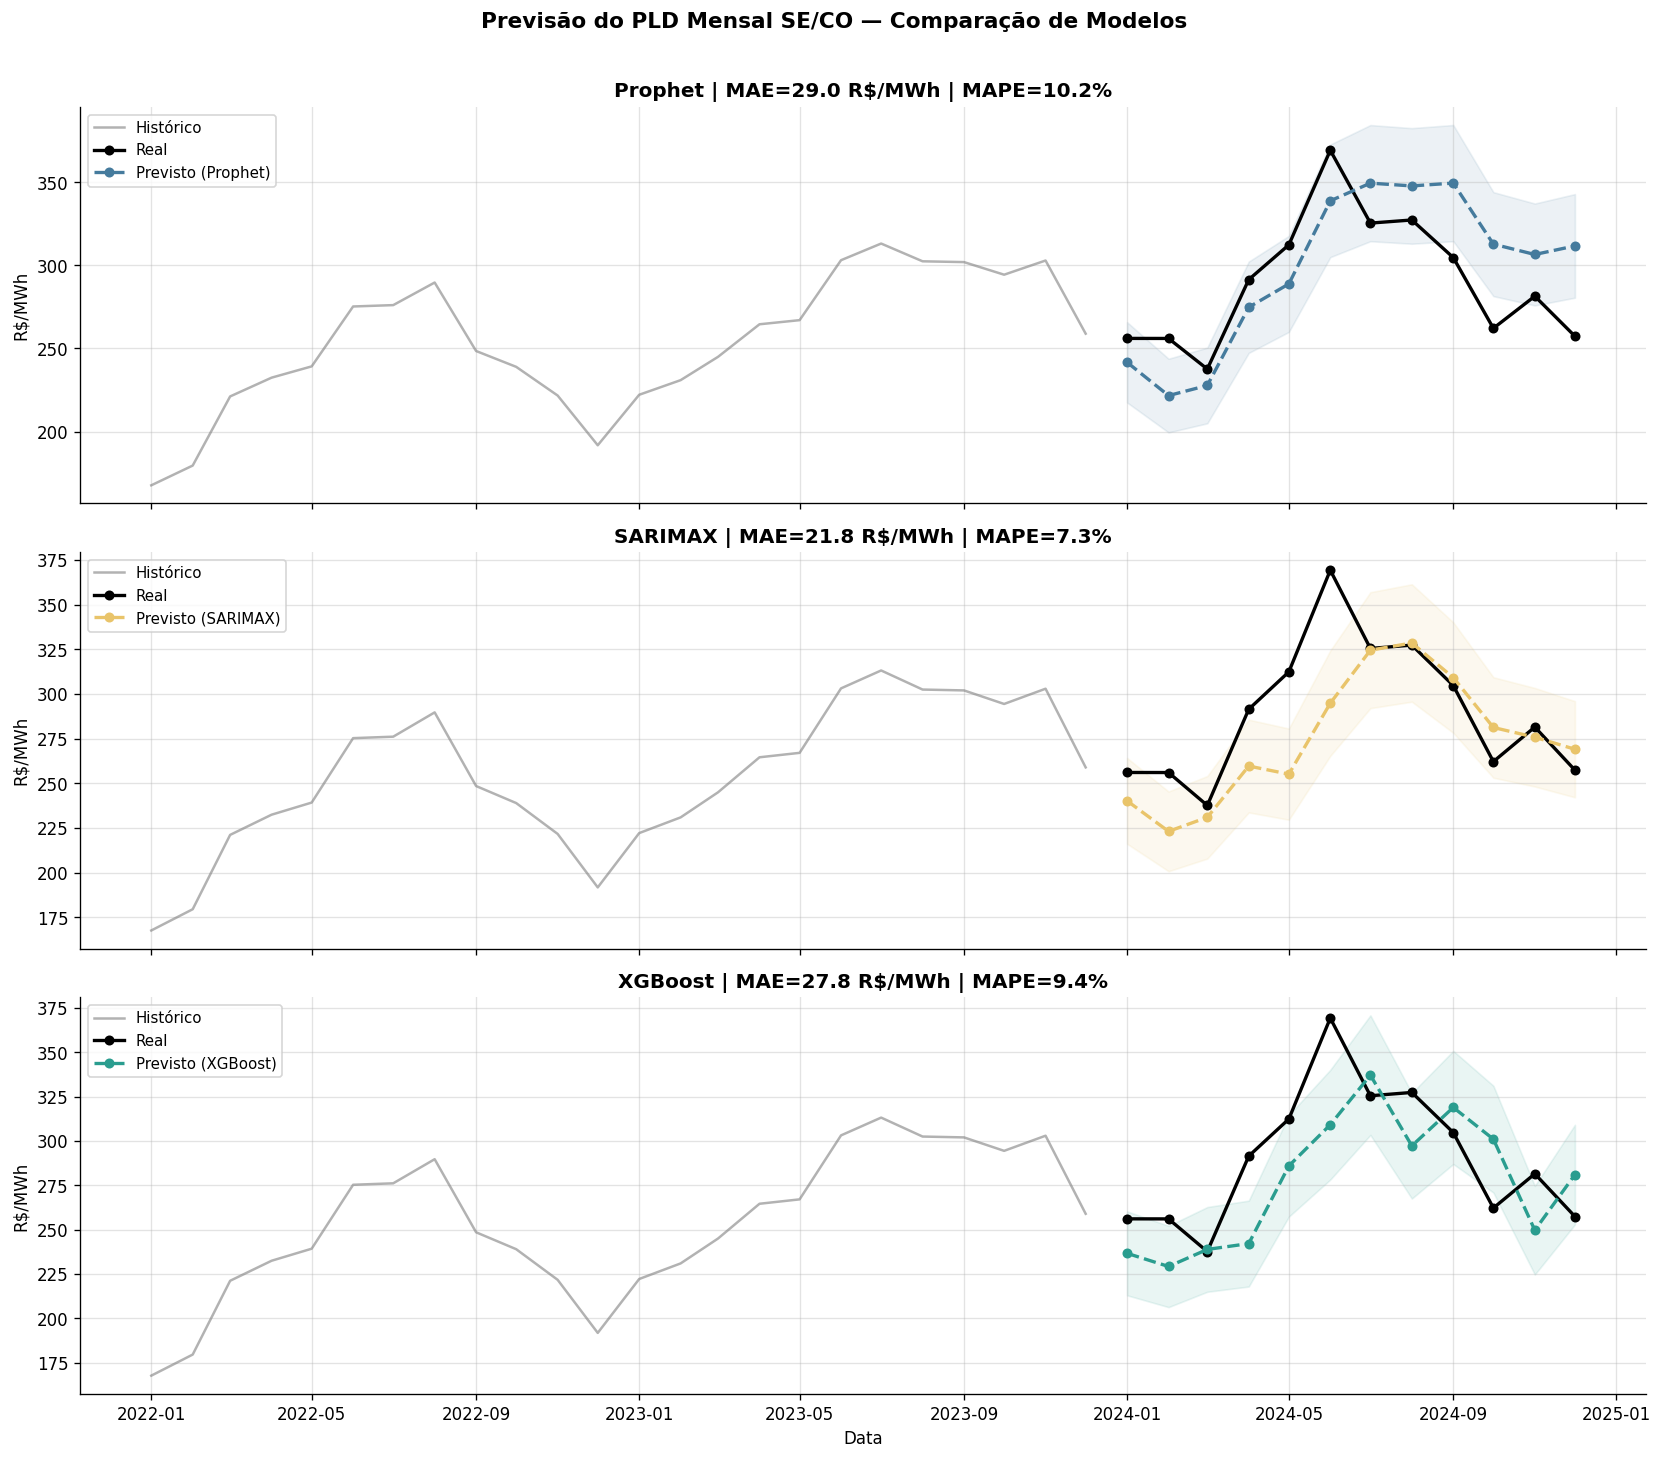

In [6]:
resultados = pd.DataFrame([res_prophet, res_sarimax, res_xgb])
resultados.to_csv(OUT_DIR / 'comparacao_modelos.csv', index=False)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
modelos = [
    ('Prophet', pred_prophet, '#457B9D'),
    ('SARIMAX', pred_sarimax.values, '#E9C46A'),
    ('XGBoost', pred_xgb, '#2A9D8F'),
]
datas_test = test['din_referencia'].values

for ax, (nome, pred, cor) in zip(axes, modelos):
    # Contexto histórico
    ax.plot(train['din_referencia'].values[-24:], train['val_pld'].values[-24:],
            color='gray', lw=1.5, alpha=0.6, label='Histórico')
    ax.plot(datas_test, y_test, 'k-o', lw=2, ms=5, label='Real')
    ax.plot(datas_test, pred, '--o', color=cor, lw=2, ms=5, label=f'Previsto ({nome})')

    # Banda de erro ±10%
    ax.fill_between(datas_test, pred*0.9, pred*1.1, alpha=0.1, color=cor)

    mae_  = mean_absolute_error(y_test, pred)
    mape_ = mape(y_test, pred)
    ax.set_title(f'{nome} | MAE={mae_:.1f} R$/MWh | MAPE={mape_:.1f}%', fontweight='bold')
    ax.set_ylabel('R$/MWh')
    ax.legend(fontsize=9)

axes[-1].set_xlabel('Data')
fig.suptitle('Previsão do PLD Mensal SE/CO — Comparação de Modelos', y=1.01,
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR / 'modelo_01_comparacao_previsoes.png', bbox_inches='tight')
plt.show()


## 6. Importância de Features — XGBoost

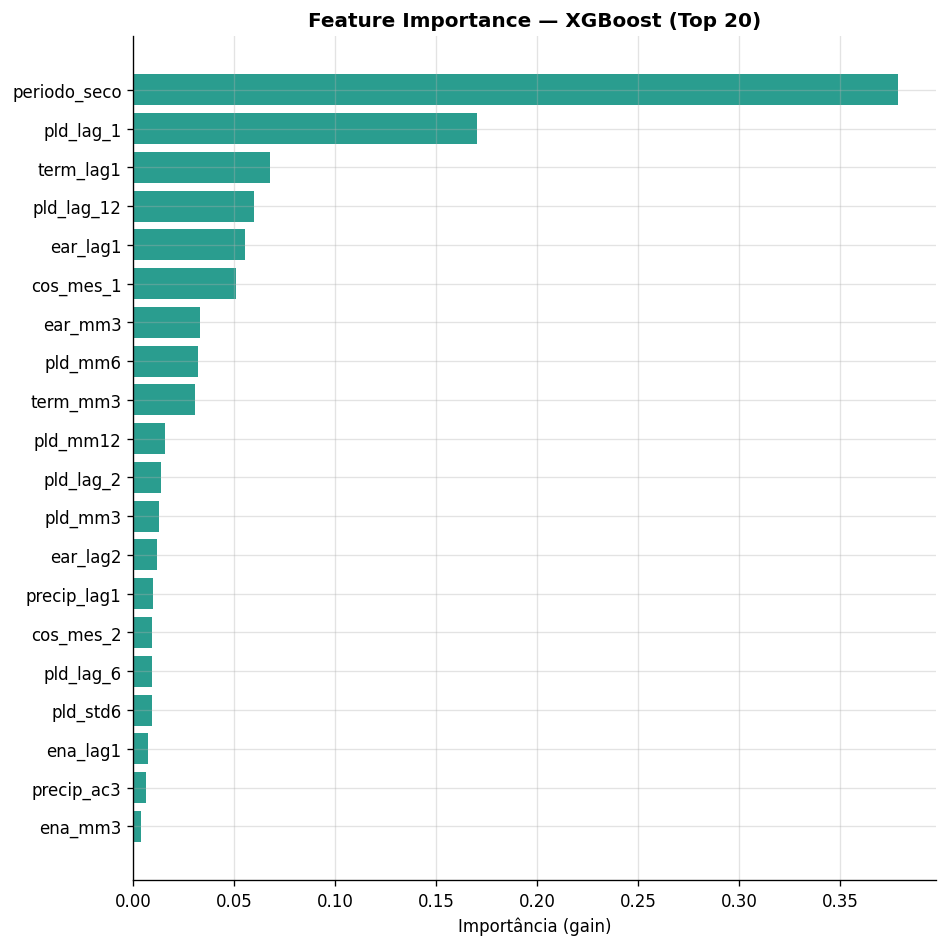

In [7]:
import_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': m_xgb.feature_importances_
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(import_df['feature'], import_df['importance'], color='#2A9D8F', edgecolor='none')
ax.set_title('Feature Importance — XGBoost (Top 20)', fontweight='bold')
ax.set_xlabel('Importância (gain)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'modelo_02_feature_importance.png', bbox_inches='tight')
plt.show()
